# 17_01 — Simulación y preprocesamiento · **Escenario A: FAR(1) con tendencia**

Paso **1 de 3** del ciclo `Python → MATLAB → Python`:

| Paso | Archivo | Qué hace |
|---|---|---|
| 1 | **este notebook** | genera los datos, ajusta base + FPCA + estandarizador, escribe los datasets AR y todos los artefactos |
| 2 | `psbp_fd_iteracion.m` | muestreo MCMC en MATLAB, sólo con el bloque de entrenamiento |
| 3 | `17_03_convergencia` / `17_04_evaluacion` | diagnóstico de cadenas y evaluación fuera de muestra |

Las celdas marcadas **`[CONFIG]`** son las únicas que se tocan al cambiar de
experimento. Todo lo demás se deriva de ellas.

---

## Qué es el Escenario A y por qué existe

**No es un Algoritmo del anexo.** Los seis escenarios de `docs/01 Anexo.tex`
intervienen la ley condicional (Bloque 1) o la reducción de dimensión
(Bloque 2), pero los seis son **estacionarios en media**. Este escenario es un
diagnóstico del propio *pipeline*: toma el Algoritmo 1 —FAR(1) lineal gaussiano
homogéneo, el control— y le suma una **tendencia determinista en $t$**:

$$X_t(\tau) \;=\; \underbrace{\mu(\tau) + Y_t(\tau)}_{\text{Algoritmo 1}} \;+\; \underbrace{b(t)\,g(\tau)}_{\text{tendencia}},$$

con $Y_t$ el FAR(1) estacionario, $b(t)$ creciente y $g(\tau)$ la forma sobre
el dominio. Se nombra con **letra** (`ESCENARIO_ID = "A"`) para que no colisione
con los ids 1–6 ni se confunda con una réplica de aquellos.

### Por qué la tendencia sí interviene y una media $\mu(\tau)$ no

Es la distinción que este notebook existe para verificar. Una media constante
en $t$ —incluida una afín en $\tau$— **se cancela exactamente**: la proyección a
base es lineal y el estandarizador resta la media empírica, de modo que

$$\mathrm{proj}(X_t) = \mathrm{proj}(\mu) + \mathrm{proj}(X_t-\mu),$$

y el centrado elimina $\mathrm{proj}(\mu)$. Cambiar $\mu(\tau)$ reproduce los
scores hasta redondeo y no es una palanca del estudio.

Con $b(t)$ **no ocurre eso**, y por tres vías distintas que conviene no
confundir:

1. **El centrado deja de ser válido fuera de muestra.** La media empírica se
   ajusta sobre $t \in \{1,\dots,T_0\}$, y el bloque de prueba está
   sistemáticamente por encima de ella. El sesgo no se aprende: es una
   propiedad del ajuste.
2. **El FPCA reasigna su espectro.** La deriva es una dirección de varianza
   grande, así que una FPC se alinea con $g(\tau)$ y su score se vuelve una
   serie de raíz cuasi-unitaria. Con $M$ fijo, esa componente **desplaza** a
   una de las que describían la dinámica del FAR(1).
3. **El modelo AR sobre scores queda mal especificado.** El PSBP recibe un
   regresor con tendencia y una respuesta con tendencia sobre un bloque en que
   ambas son casi colineales; nada en el muestreador lo advierte.

### Qué se verifica, y en qué orden

| Verificación | Dónde | Resultado esperado |
|---|---|---|
| la tendencia se inyectó con la pendiente pedida | `_01 §2.3` | `assert` sobre la regresión del nivel en $b(t)$ |
| el centrado NO transfiere al test | `_01 §3.5` | `max\|media ξ_test\|` **grande** (en la corrida 11: 0.063) |
| una FPC capta la deriva | `_01 §3.4` | `ar1_propio` de esa componente $\to 1$ |
| las cadenas convergen igual | `_03` | ✓ — la no estacionariedad no rompe el muestreador |
| el error crece **monótonamente** en el test | `_04 §7` | ventana móvil con pendiente, no un escalón |
| el error es **de nivel**, no de forma | `_04 §9` | `MISE_forma / MISE` pequeño |

**La lectura central**: si `_04 §9` muestra que casi todo el error del test es
de nivel y no de forma, lo que falla no es el modelo predictivo sino la
**vigencia del centrado**, y la conclusión práctica es que el pipeline requiere
una etapa de des-tendenciado previa —no un modelo más flexible.

## 1. Imports y rutas

In [1]:
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Generadores y contrato de artefactos
from model_psbp_fd.pipelines import (
    ConfigEscenario1, generar_escenario_1, guardar_escenario,
    guardar_curvas, guardar_representacion, guardar_fpca,
    guardar_estandarizador, guardar_datasets_ar,
    guardar_hiperparametros, guardar_config_evaluacion,
    verificar_contrato,
)
# Preprocesamiento funcional
from model_psbp_fd.functions_models import (
    FunctionalRepresentation, FPCA_L2, base_en_grilla, DataStandardizer,
)
from model_psbp_fd.fit import tabla_baselines
from model_psbp_fd.utils import get_project_root
from model_psbp_fd.graphics import (
    plot_empirical_sample, plot_mean_and_variance, plot_fts_empirical,
    plot_fts_functional, plot_diagnostico_estandarizacion, plot_fpca_scree,
    plot_seleccion_basis, plot_rezagos_heatmap,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

### 1.1 `[CONFIG]` Identificación del experimento

`ESCENARIO_ID` es una **cadena**, no un entero: el `psbp_fd_iteracion.m` de esta
carpeta usa `%s` en su `sprintf` por ese motivo. Si se cambia a un número hay
que cambiar el `.m` también — la coincidencia exacta de `EXPERIMENT_ID` es lo
único que empareja los artefactos de los dos lados.

In [2]:
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

BASENAME     = "escenario"
ESCENARIO_ID = "A"    # escenario de diagnóstico; NO es un Algoritmo del anexo
REPLICA_ID   = 1      # réplica Monte Carlo; eje del barrido en la Etapa D
SEED         = 41232  # semilla base; MATLAB la LEE de hyperparameters.json

EXPERIMENT_ID = f"{BASENAME}_{ESCENARIO_ID}_r{REPLICA_ID:02d}"

print(f"PROJECT_ROOT  : {PROJECT_ROOT}")
print(f"EXPERIMENT_ID : {EXPERIMENT_ID}")
print(f"Escenario {ESCENARIO_ID} · réplica {REPLICA_ID} · seed base {SEED}")

PROJECT_ROOT  : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
EXPERIMENT_ID : escenario_A_r01
Escenario A · réplica 1 · seed base 41232


In [3]:
# Las cinco rutas del contrato. No existe un config_paths en Python: cada
# notebook lo arma aquí y config_paths.m replica las mismas del lado MATLAB.
PATHS = {
    "raw":          PROJECT_ROOT / "data" / "simulaciones" / "raw" / EXPERIMENT_ID,
    "functional":   PROJECT_ROOT / "data" / "simulaciones" / "processed" / "functional" / EXPERIMENT_ID,
    "predict":      PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict" / EXPERIMENT_ID,
    "out_report":   PROJECT_ROOT / "reports" / "simulaciones" / EXPERIMENT_ID,
    "out_artefact": PROJECT_ROOT / "artefact" / "simulaciones" / EXPERIMENT_ID,
}
for nombre, ruta in PATHS.items():
    ruta.mkdir(parents=True, exist_ok=True)
    print(f"  {nombre:12s} → {ruta}")

  raw          → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_A_r01
  functional   → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\escenario_A_r01
  predict      → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\predict\escenario_A_r01
  out_report   → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\escenario_A_r01
  out_artefact → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_A_r01


## 2. Simulación

### 2.1 `[CONFIG]` Parámetros del generador

`L`, `T`, `PROP_TRAIN` y `sigma_obs` son los **parámetros fijos del estudio** y
se mantienen idénticos a los de la corrida 11. Los del Algoritmo 1 —`gamma`,
`hs_norm`, `sigma_eps`, `ell`— también. **Lo único que cambia es la tendencia**,
para que la comparación 11 vs A aísle exactamente ese efecto y no mezcle
diseños de observación.

La media $\mu(\tau)$ es la vigente del estudio, `sin(2πτ)`, y **no** la
`5 + 2 sin(2πτ)` con que corrió la 11. La diferencia es un desplazamiento
constante que el centrado absorbe, de modo que no afecta a la comparación; se
usa la vigente porque es la del Cuadro `tab:ane_esquema`.

In [4]:
# ── Parámetros fijos del estudio (comunes a los 6 escenarios) ────────────────
L_GRILLA   = 75     # puntos de la grilla regular tau_1=0 … tau_L=1
T_CURVAS   = 400    # curvas retenidas tras el calentamiento
PROP_TRAIN = 0.70   # proporción del bloque de entrenamiento  → T0 = 280
SIGMA_OBS  = 0.25   # desviación del ruido de medición

def media_senoidal(tau):
    """mu(tau) = sin(2 pi tau). La media vigente del estudio (tab:ane_esquema)."""
    return np.sin(2.0 * np.pi * tau)

SIM_CFG = ConfigEscenario1(
    # Esquema de observación — idéntico a la corrida 11
    L         = L_GRILLA,
    T         = T_CURVAS,
    burn_in   = 200,
    sigma_obs = SIGMA_OBS,
    R         = 1,            # una réplica por corrida; el barrido usa REPLICA_ID
    seed      = SEED,
    media_fn  = media_senoidal,
    # Operador autorregresivo — idéntico a la corrida 11
    gamma     = 0.3,
    hs_norm   = 0.7,
    # Innovación funcional — idéntica a la corrida 11
    sigma_eps = 1.0,
    ell       = 0.2,
)

for k, v in SIM_CFG.to_dict().items():
    print(f"  {k:<12}: {v}")

  L           : 75
  T           : 400
  burn_in     : 200
  sigma_obs   : 0.25
  R           : 1
  seed        : 41232
  media_fn    : media_senoidal
  jitter      : 1e-10
  gamma       : 0.3
  hs_norm     : 0.7
  sigma_eps   : 1.0
  ell         : 0.2


### 2.2 `[CONFIG]` La tendencia

Tres parámetros, y cada uno controla una cosa distinta:

- **`TEND_DERIVA`** — desplazamiento **total acumulado** entre $t=1$ y $t=T$, en
  las mismas unidades que $X$. Es el parámetro que fija la magnitud del efecto.
  Con $\mathrm{sd}(X)\approx 1.17$ en el Algoritmo 1, un valor de `3.0` son unas
  **2.6 desviaciones** de deriva total; el desfase medio entre el bloque de
  entrenamiento y el de prueba resulta $\approx 1.5$, es decir **1.3 sd**. Es
  grande a propósito: el escenario debe producir un efecto inequívoco, no uno
  que haya que discutir contra el ruido Monte Carlo de $R=1$.
- **`TEND_FORMA`** — cómo se acumula. `"lineal"` reparte la deriva
  uniformemente; `"cuadratica"` la concentra al final, de modo que el bloque de
  entrenamiento apenas la ve y el salto en $T_0$ es más violento. La lineal es
  el caso base porque es el que un des-tendenciado ingenuo *debería* poder
  corregir.
- **`TEND_INCLINACION`** — la forma $g(\tau) = 1 + c(\tau - 1/2)$. Con `c = 0`
  la deriva es de **nivel puro**: idéntica en todo el dominio. Ése es el caso
  base y el que hace interpretable la descomposición nivel/forma de `_04 §9`.
  Con `c \neq 0` la deriva inclina la curva y contamina también la forma, lo
  cual es más realista pero mezcla los dos efectos que el escenario quiere
  separar.

**Recomendación**: correr primero con los valores por defecto
(`3.0`, `"lineal"`, `0.0`). Los otros dos ejes son variaciones para después,
y cambiarlos exige cambiar `EXPERIMENT_ID` para no sobrescribir.

In [5]:
TEND_DERIVA      = 3.0        # deriva TOTAL acumulada entre t=1 y t=T, en unidades de X
TEND_FORMA       = "lineal"   # "lineal" | "cuadratica"
TEND_INCLINACION = 0.0        # 0 ⇒ deriva de nivel puro (idéntica en todo tau)


def perfil_tendencia(t_idx, T, forma):
    """
    b(t) / TEND_DERIVA en [0, 1]: fracción de la deriva total acumulada en t.

    Normalizada de modo que b(1) = 0 y b(T) = TEND_DERIVA, para que
    TEND_DERIVA se lea directamente como el desplazamiento total y no dependa
    de T ni de la forma elegida.
    """
    u = (np.asarray(t_idx, dtype=float) - 1.0) / (T - 1.0)
    if forma == "lineal":
        return u
    if forma == "cuadratica":
        return u ** 2
    raise ValueError(f"TEND_FORMA no reconocida: {forma!r}")


def g_tendencia(tau, inclinacion):
    """Forma funcional de la deriva. inclinacion=0 ⇒ constante e igual a 1."""
    return 1.0 + inclinacion * (np.asarray(tau, dtype=float) - 0.5)

### 2.3 Generación e inyección de la tendencia

In [6]:
salida = generar_escenario_1(SIM_CFG)

REPLICA_IDX = REPLICA_ID - 1
grilla = salida.grilla
T, G   = salida.observaciones[REPLICA_IDX].shape

# Diagnóstico del generador ANTES de la tendencia: es el del proceso
# estacionario y es el que se compara con la corrida 11. Se guarda aparte
# porque después de inyectar la deriva deja de describir los datos.
diagnostico_estacionario = dict(salida.diagnostico)

# ── Tendencia ────────────────────────────────────────────────────────────────
t_idx = np.arange(1, T + 1)
b_t   = TEND_DERIVA * perfil_tendencia(t_idx, T, TEND_FORMA)   # (T,)
g_tau = g_tendencia(grilla, TEND_INCLINACION)                  # (G,)
TREND = np.outer(b_t, g_tau)                                   # (T, G)

# Se suma a las DOS matrices. La tendencia es parte de la curva verdadera, no
# ruido de medición: sumarla a ambas deja intacta la diferencia observada −
# verdadera, que sigue siendo exactamente el ruido de sigma_obs.
X_true = salida.curvas[REPLICA_IDX]       + TREND   # (T, G) VERDADERA — objetivo de evaluación
X_raw  = salida.observaciones[REPLICA_IDX] + TREND  # (T, G) OBSERVADA — alimenta la estimación

# Se sobrescribe la salida para que el .npz guarde el escenario REAL y no la
# componente estacionaria. Quien cargue el artefacto obtiene lo que se simuló.
salida.curvas[REPLICA_IDX]       = X_true
salida.observaciones[REPLICA_IDX] = X_raw

print(f"Observadas {X_raw.shape} · verdaderas {X_true.shape} · grilla {grilla.shape}")
print(f"Ruido de medición efectivo: sd(X_raw - X_true) = {(X_raw - X_true).std():.4f}"
      f"   (nominal {SIGMA_OBS})")
print(f"\nTendencia: forma={TEND_FORMA!r}  deriva total={TEND_DERIVA}  "
      f"inclinación={TEND_INCLINACION}")
print(f"  b(1)={b_t[0]:.3f}   b(T0)={b_t[279]:.3f}   b(T)={b_t[-1]:.3f}")
print(f"  g(tau) ∈ [{g_tau.min():.3f}, {g_tau.max():.3f}]"
      + ("   (nivel puro)" if TEND_INCLINACION == 0 else "   (inclinada)"))

print("\nControl de calidad del generador (componente ESTACIONARIA, sin tendencia):")
for k, v in diagnostico_estacionario.items():
    print(f"  {k:32s} = {v}")

Observadas (400, 75) · verdaderas (400, 75) · grilla (75,)
Ruido de medición efectivo: sd(X_raw - X_true) = 0.2503   (nominal 0.25)

Tendencia: forma='lineal'  deriva total=3.0  inclinación=0.0
  b(1)=0.000   b(T0)=2.098   b(T)=3.000
  g(tau) ∈ [1.000, 1.000]   (nivel puro)

Control de calidad del generador (componente ESTACIONARIA, sin tendencia):
  n_replicas                       = 1
  n_curvas                         = 400
  n_puntos_grilla                  = 75
  todo_finito                      = True
  media_empirica_global            = -0.04193124048944612
  media_ee_montecarlo              = nan
  var_puntual_media                = 1.3793612307343184
  var_puntual_min                  = 1.031380128400936
  var_puntual_max                  = 1.5750470588165846
  acf1_media                       = 0.45724202279425025
  acf1_ee_montecarlo               = nan
  razon_senal_ruido                = 22.069779691749094
  hs_norm_objetivo                 = 0.7
  hs_norm_efectiva        

### 2.4 Verificación de la inyección

Análogo a la reconstrucción de $p_t$ de la corrida 13 y del residuo AR de la 14:
antes de seguir, se comprueba que lo que se sumó es lo que se quería sumar. Se
regresa el **nivel puntual** de cada curva —su media sobre $\tau$— contra
$b(t)$, y la pendiente debe recuperar $\overline{g(\tau)}$.

El coeficiente sale con error de muestreo porque el FAR(1) subyacente aporta su
propia variación al nivel; la tolerancia del `assert` está dimensionada para
eso, no es holgura arbitraria.

In [7]:
nivel_t = X_true.mean(axis=1)                       # (T,) nivel puntual de cada curva
g_medio = float(g_tau.mean())

# OLS de nivel_t sobre [1, b_t]
Z    = np.column_stack([np.ones(T), b_t])
coef = np.linalg.lstsq(Z, nivel_t, rcond=None)[0]
pend, interc = float(coef[1]), float(coef[0])

# Error estándar de la pendiente, para dimensionar la tolerancia
resid  = nivel_t - Z @ coef
s2     = float(resid @ resid) / (T - 2)
ee_pend = float(np.sqrt(s2 * np.linalg.inv(Z.T @ Z)[1, 1]))

print(f"pendiente estimada : {pend:.4f}   (esperada g_medio = {g_medio:.4f})")
print(f"error estándar     : {ee_pend:.4f}   →  |t| desvío = "
      f"{abs(pend - g_medio) / ee_pend:.2f}")
print(f"intercepto         : {interc:.4f}   (≈ media de mu(tau) = "
      f"{float(media_senoidal(grilla).mean()):.4f})")

assert abs(pend - g_medio) < 4.0 * ee_pend, (
    f"La pendiente recuperada ({pend:.4f}) no coincide con g_medio ({g_medio:.4f}) "
    f"dentro de 4 EE ({ee_pend:.4f}). La tendencia NO se inyectó como se pidió.")

# Cuánto pesa la deriva frente a la variación estacionaria: si esta razón es
# baja el escenario no tiene contenido y la conclusión sería sobre el ruido.
sd_estacionaria = float(np.sqrt(diagnostico_estacionario["var_puntual_media"]))
razon_deriva_sd = TEND_DERIVA / sd_estacionaria
print(f"\nderiva total / sd(X) = {razon_deriva_sd:.2f} sd")
print(f"desfase medio train↔test = {b_t[280:].mean() - b_t[:280].mean():.3f}"
      f"  =  {(b_t[280:].mean() - b_t[:280].mean()) / sd_estacionaria:.2f} sd")
assert razon_deriva_sd > 1.0, (
    "La deriva es menor que una desviación estándar: el escenario no produce "
    "un efecto separable del ruido con R=1. Subir TEND_DERIVA.")
print("\n✓ tendencia verificada")

pendiente estimada : 1.0130   (esperada g_medio = 1.0000)
error estándar     : 0.0492   →  |t| desvío = 0.26
intercepto         : -0.0614   (≈ media de mu(tau) = -0.0000)

deriva total / sd(X) = 2.55 sd
desfase medio train↔test = 1.504  =  1.28 sd

✓ tendencia verificada


### 2.5 Persistencia del estado verdadero

El **estado verdadero** de este escenario es $b(t)$, y se persiste igual que
`interno_sigma2` en la corrida 12, los regímenes en la 13 y `quiebre_idx` en la
16: en un CSV propio que `_04 §9` lee para estratificar.

**La advertencia que hay que arrastrar** —y que es la misma de la corrida 16—:
$b(t)$ es **monótona en $t$**, de modo que cualquier estrato por nivel de
tendencia es un intervalo temporal contiguo y el estrato más alto **coincide
casi exactamente con el bloque de prueba**. La cobertura condicional de `_04 §9`
y la comparación train/test de `_04 §4` miden por tanto **lo mismo**. No es un
defecto: es la tesis del escenario. Pero sin declararlo, el desplome de
cobertura se leería como pérdida de *generalización* cuando es pérdida de
*vigencia del centrado*. Queda escrito en `eval_config.json` para que viaje con
los datos.

In [8]:
T0_prov = int(np.floor(PROP_TRAIN * T_CURVAS))   # provisional; se recalcula en 2.7

estado_tend = pd.DataFrame({
    "t":              t_idx,                       # base-1, tiempo del experimento
    "b_t":            b_t,                         # estado verdadero: deriva acumulada
    "b_t_norm":       b_t / max(TEND_DERIVA, 1e-12),
    "nivel_curva":    nivel_t,                     # media sobre tau de X_true
    "nivel_sin_tend": nivel_t - b_t * g_medio,     # nivel de la componente estacionaria
    "bloque":         np.where(t_idx <= T0_prov, "train", "test"),
})
estado_tend.to_csv(PATHS["out_report"] / "10_estado_tendencia.csv", index=False)

print(estado_tend.head(3).to_string(index=False))
print("...")
print(estado_tend.tail(3).to_string(index=False))
print(f"\n[report] 10_estado_tendencia.csv  ({len(estado_tend)} filas)")

# La contigüidad temporal de los estratos, medida y no supuesta.
q = np.quantile(b_t, [0.25, 0.50, 0.75])
estrato = np.digitize(b_t, q)
frac_test_por_estrato = [float((t_idx[estrato == e] > T0_prov).mean()) for e in range(4)]
print("\nfracción del estrato que cae en el bloque de PRUEBA:")
for e, f in enumerate(frac_test_por_estrato):
    print(f"  estrato {e} (b ∈ cuartil {e+1}): {f:6.1%}")
print("\n⚠ Los estratos extremos son casi disjuntos con la partición train/test.\n"
      "  §9 de 17_04 y §4 de 17_04 miden lo mismo. Declararlo al reportar.")

 t      b_t  b_t_norm  nivel_curva  nivel_sin_tend bloque
 1 0.000000  0.000000     1.297758        1.297758  train
 2 0.007519  0.002506     1.013393        1.005874  train
 3 0.015038  0.005013    -0.381377       -0.396415  train
...
  t      b_t  b_t_norm  nivel_curva  nivel_sin_tend bloque
398 2.984962  0.994987     2.556281       -0.428681   test
399 2.992481  0.997494     2.888034       -0.104447   test
400 3.000000  1.000000     2.190690       -0.809310   test

[report] 10_estado_tendencia.csv  (400 filas)

fracción del estrato que cae en el bloque de PRUEBA:
  estrato 0 (b ∈ cuartil 1):   0.0%
  estrato 1 (b ∈ cuartil 2):   0.0%
  estrato 2 (b ∈ cuartil 3):  20.0%
  estrato 3 (b ∈ cuartil 4): 100.0%

⚠ Los estratos extremos son casi disjuntos con la partición train/test.
  §9 de 17_04 y §4 de 17_04 miden lo mismo. Declararlo al reportar.


In [9]:
# Configuración de simulación + escenario completo en .npz
simulation_config = {
    "sim_params":    salida.config.to_dict(),
    "diagnostico_estacionario": diagnostico_estacionario,
    "tendencia": {
        "deriva_total":     float(TEND_DERIVA),
        "forma":            TEND_FORMA,
        "inclinacion":      float(TEND_INCLINACION),
        "g_medio":          g_medio,
        "b_T0":             float(b_t[T0_prov - 1]),
        "b_T":              float(b_t[-1]),
        "desfase_train_test": float(b_t[T0_prov:].mean() - b_t[:T0_prov].mean()),
        "razon_deriva_sd":  float(razon_deriva_sd),
        "pendiente_verificada": pend,
        "nota": ("X_t(tau) = mu(tau) + Y_t(tau) + b(t) g(tau), con Y_t el FAR(1) "
                 "del Algoritmo 1. El .npz y los .npy guardan la serie CON "
                 "tendencia; diagnostico_estacionario describe Y_t solamente."),
    },
    "replica_idx":   REPLICA_IDX,
    "experiment_id": EXPERIMENT_ID,
    "escenario_id":  ESCENARIO_ID,     # cadena "A", no entero
    "replica_id":    int(REPLICA_ID),
    "seed":          SEED,
    "T": int(T), "G": int(G),
}
with open(PATHS["raw"] / "simulation_config.json", "w", encoding="utf-8") as f:
    json.dump(simulation_config, f, indent=2, ensure_ascii=False)

_npz = guardar_escenario(salida, str(PATHS["raw"] / f"escenario_{ESCENARIO_ID}"),
                         incluir_curvas=True, incluir_internos=True)
print(f"[raw] simulation_config.json  ·  {_npz}")

[raw] simulation_config.json  ·  C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\escenario_A_r01\escenario_A.npz


### 2.6 Visualización de los datos

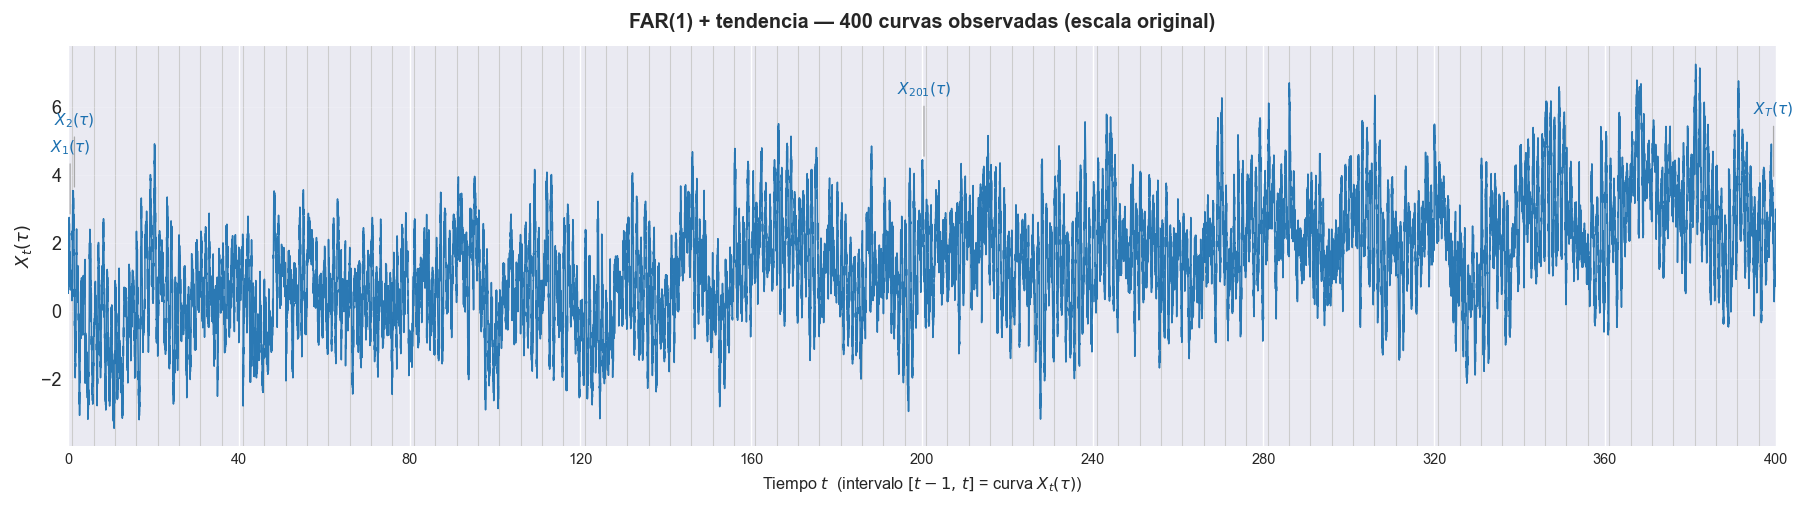

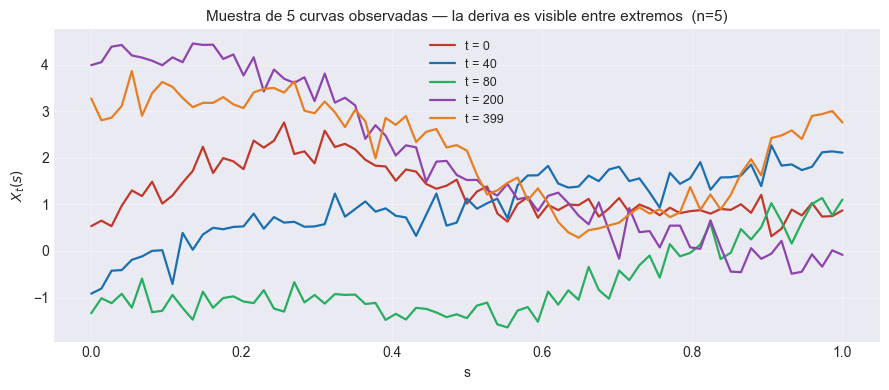

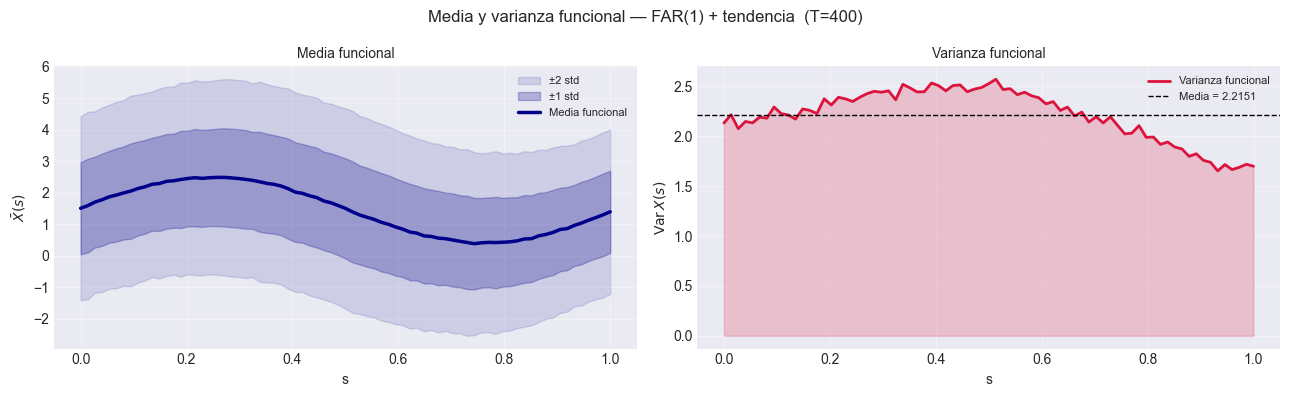

In [10]:
highlight_idx = [0, 1, T // 2, T - 1]

plot_fts_empirical(
    X_raw, grilla, highlight_idx=highlight_idx, separator_every=5,
    title=f"FAR(1) + tendencia — {T} curvas observadas (escala original)",
    save_path=str(PATHS["out_report"] / "01_fts_empirica_raw.png"))
plt.show()

plot_empirical_sample(
    X_raw, grilla, sample_idx=[0, 40, 80, 200, T - 1],
    title="Muestra de 5 curvas observadas — la deriva es visible entre extremos",
    save_path=str(PATHS["out_report"] / "02_muestra_empirica_raw.png"))
plt.show()

plot_mean_and_variance(
    X_raw, grilla, show_std1=True, show_std2=True,
    title="Media y varianza funcional — FAR(1) + tendencia",
    save_path=str(PATHS["out_report"] / "03_media_varianza_raw.png"))
plt.show()

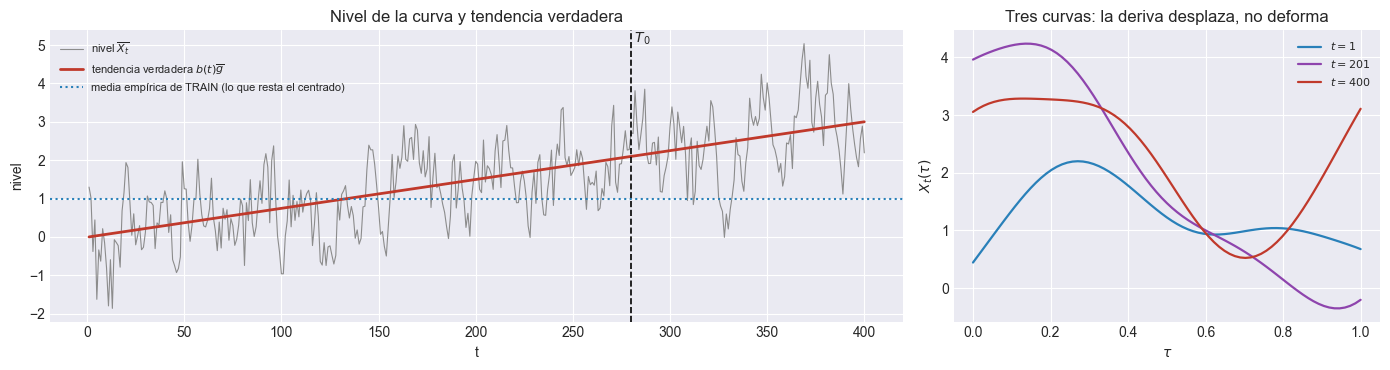

media(train) = 0.989   media(test) = 2.553   desfase = +1.564
← ese desfase es el sesgo que el modelo NO puede aprender: no está en train.


In [11]:
# La figura propia del escenario: el nivel de la curva contra t, con la
# tendencia verdadera superpuesta y el corte train/test marcado. Es la que
# hace evidente por qué el centrado ajustado en train no sirve en test.
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8),
                         gridspec_kw={"width_ratios": [2, 1]})

ax = axes[0]
ax.plot(t_idx, nivel_t, lw=0.8, color="0.55", label=r"nivel $\overline{X_t}$")
ax.plot(t_idx, b_t * g_medio + float(media_senoidal(grilla).mean()),
        lw=2.0, color="#c0392b", label=r"tendencia verdadera $b(t)\overline{g}$")
ax.axvline(T0_prov, color="k", ls="--", lw=1.2)
ax.axhline(nivel_t[:T0_prov].mean(), color="#2980b9", ls=":", lw=1.5,
           label="media empírica de TRAIN (lo que resta el centrado)")
ax.text(T0_prov, ax.get_ylim()[1], r" $T_0$", va="top", fontsize=10)
ax.set_xlabel("t"); ax.set_ylabel("nivel")
ax.set_title("Nivel de la curva y tendencia verdadera")
ax.legend(fontsize=8, loc="upper left")

ax = axes[1]
for i, col in ((0, "#2980b9"), (T // 2, "#8e44ad"), (T - 1, "#c0392b")):
    ax.plot(grilla, X_true[i], color=col, lw=1.6, label=rf"$t={i+1}$")
ax.set_xlabel(r"$\tau$"); ax.set_ylabel(r"$X_t(\tau)$")
ax.set_title("Tres curvas: la deriva desplaza, no deforma")
ax.legend(fontsize=8)

fig.tight_layout()
fig.savefig(PATHS["out_report"] / "11_tendencia.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"media(train) = {nivel_t[:T0_prov].mean():.3f}   "
      f"media(test) = {nivel_t[T0_prov:].mean():.3f}   "
      f"desfase = {nivel_t[T0_prov:].mean() - nivel_t[:T0_prov].mean():+.3f}")
print("← ese desfase es el sesgo que el modelo NO puede aprender: no está en train.")

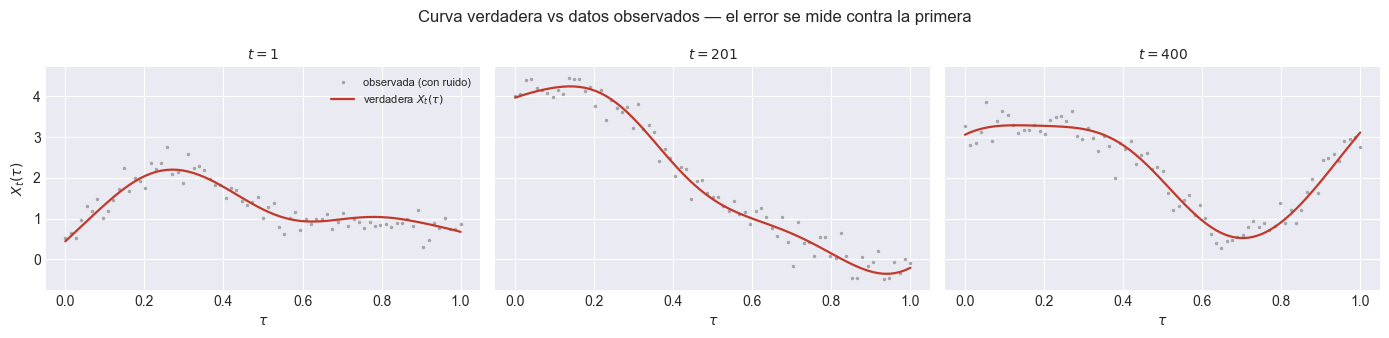

In [12]:
# Curva observada vs verdadera: dimensiona el ruido que el modelo NO debe predecir
fig, axes = plt.subplots(1, 3, figsize=(14, 3.4), sharey=True)
for ax, i in zip(axes, [0, T // 2, T - 1]):
    ax.plot(grilla, X_raw[i], ".", color="0.65", ms=3, label="observada (con ruido)")
    ax.plot(grilla, X_true[i], color="#c0392b", lw=1.6, label="verdadera $X_t(\\tau)$")
    ax.set_title(rf"$t={i+1}$", fontsize=10); ax.set_xlabel(r"$\tau$")
axes[0].set_ylabel(r"$X_t(\tau)$"); axes[0].legend(fontsize=8)
fig.suptitle("Curva verdadera vs datos observados — el error se mide contra la primera",
             fontsize=12)
fig.tight_layout()
fig.savefig(PATHS["out_report"] / "04_curva_vs_datos.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.7 Persistencia de curvas y partición temporal

Se guardan las dos matrices con nombres distintos (`X_curves.npy` y
`X_curves_true.npy`) para que no puedan confundirse aguas abajo. **Ambas
incluyen la tendencia.**

Todo objeto **estimado a partir de los datos** —selección GCV de la base, FPCA,
estandarizador— se ajusta sólo con $\{1,\dots,T_0\}$ y se aplica al bloque de
prueba mediante `transform`. Bajo tendencia esa disciplina sigue siendo la
correcta: relajarla sería fuga, y el punto del escenario es medir su coste, no
evitarlo.

In [13]:
_p = guardar_curvas(PATHS, X_raw, grilla, X_true=X_true)
for clave, ruta in _p.items():
    print(f"[functional] {clave:12s} → {ruta.name}")

T0 = int(np.floor(PROP_TRAIN * T))
assert T0 == T0_prov, "T0 discrepa del provisional usado en §2.5."
assert 10 < T0 < T, f"T0={T0} fuera de rango para T={T}."

idx_train, idx_test = np.arange(0, T0), np.arange(T0, T)
X, X_train, X_test = X_raw, X_raw[idx_train], X_raw[idx_test]

print(f"\nentrenamiento : t ∈ [1, {T0}]      → {X_train.shape}")
print(f"prueba        : t ∈ [{T0+1}, {T}]  → {X_test.shape}")
print(f"proporción    : {T0/T:.1%} / {1 - T0/T:.1%}")

[functional] curvas       → X_curves.npy
[functional] grilla       → domain_grid.npy
[functional] curvas_true  → X_curves_true.npy

entrenamiento : t ∈ [1, 280]      → (280, 75)
prueba        : t ∈ [281, 400]  → (120, 75)
proporción    : 70.0% / 30.0%


## 3. Representación funcional B-spline

### 3.1 Barrido GCV sobre `(n_basis, order)`

El GCV **sugiere**; la elección es del analista y se declara en 3.2. Ojo: bajo
tendencia el GCV tiende a pedir **más** base, porque la deriva añade variación
sistemática que una base más rica ajusta mejor. Eso es un artefacto del
escenario, no una mejora: se mantiene `n_basis = 8` para que la representación
sea la misma que en la corrida 11 y la comparación siga siendo entre
generadores.

,n_basis,order,var_retained,rmse_mean,rmse_max,gcv_mean
0,2,2,65.4837%,0.725415,1.532345,0.619975
1,3,2,76.6181%,0.592830,1.314105,0.431729
2,4,2,92.1054%,0.356713,0.722797,0.149903
3,5,2,95.0106%,0.288460,0.483076,0.097465
4,6,2,95.9475%,0.261220,0.352320,0.081474
5,7,2,96.3690%,0.247617,0.327056,0.075162
6,8,2,96.5322%,0.241951,0.330903,0.073943
7,9,2,96.6446%,0.238047,0.321625,0.073732
8,10,2,96.7285%,0.235038,0.311415,0.074117
9,11,2,96.7943%,0.232624,0.312607,0.074913



GCV mínimo → n_basis=8, order=3  (var retenida 96.6206%)


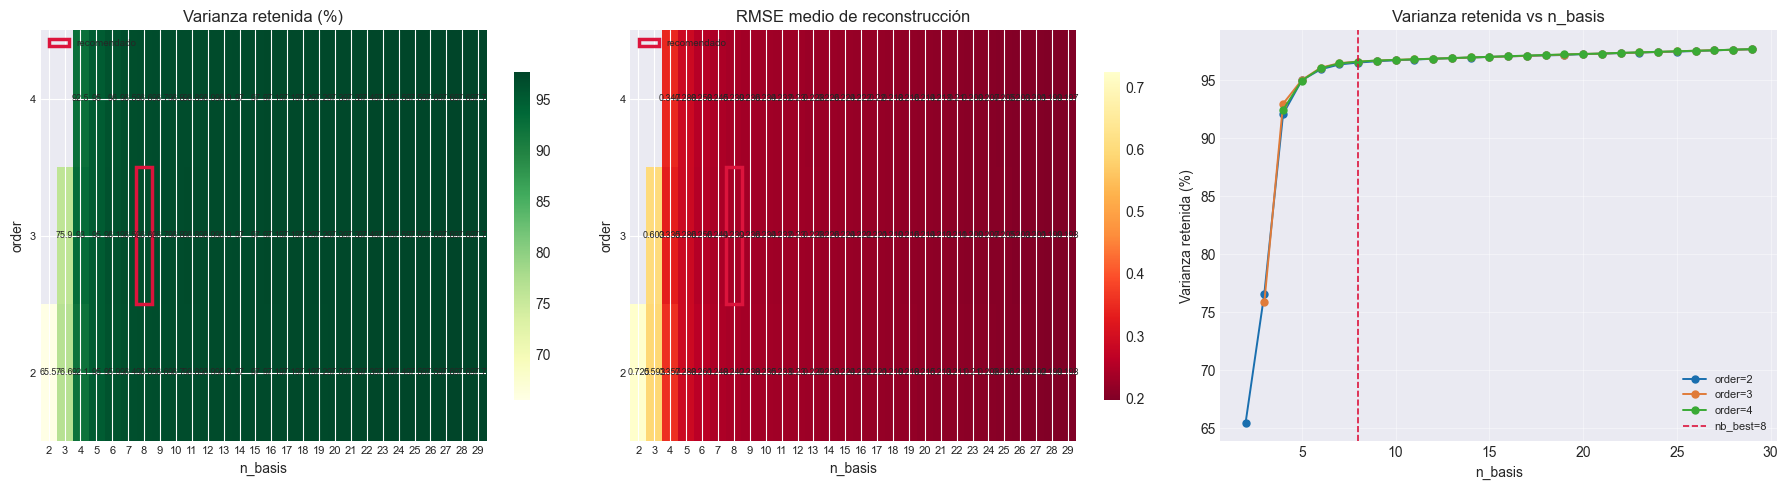

In [14]:
N_BASIS_RANGE = range(2, min(30, T0 // 2))   # acotado por T0
ORDER_RANGE   = range(2, 5)

registros = []
for orden in ORDER_RANGE:
    for nb in N_BASIS_RANGE:
        if nb < orden:
            continue
        try:
            fr_tmp = FunctionalRepresentation(method="bspline", n_basis=nb, order=orden)
            TH_tmp = fr_tmp.fit_transform(X_train, grilla)     # sólo train
            X_rec  = fr_tmp.reconstruct(TH_tmp)

            L_i    = X_train.shape[1]
            sse_c  = np.sum((X_train - X_rec) ** 2, axis=1)
            ss_tot = np.sum((X_train - X_train.mean(axis=0, keepdims=True)) ** 2)
            gcv_c  = (L_i * sse_c / (L_i - nb) ** 2 if L_i > nb
                      else np.full_like(sse_c, np.nan))
            registros.append({
                "n_basis": nb, "order": orden,
                "var_retained": 1.0 - sse_c.sum() / ss_tot,
                "rmse_mean": np.sqrt(sse_c / L_i).mean(),
                "rmse_max":  np.sqrt(sse_c / L_i).max(),
                "gcv_mean":  float(np.mean(gcv_c)),
            })
        except Exception as e:
            print(f"  [SKIP] n_basis={nb}, order={orden}: {e}")

sel_df   = pd.DataFrame(registros)
best_row = sel_df.dropna(subset=["gcv_mean"]).nsmallest(1, "gcv_mean").iloc[0]
nb_best, ord_best = int(best_row["n_basis"]), int(best_row["order"])

display(sel_df.style
    .format({"var_retained": "{:.4%}", "rmse_mean": "{:.6f}",
             "rmse_max": "{:.6f}", "gcv_mean": "{:.6f}"})
    .background_gradient(subset=["gcv_mean"], cmap="YlOrRd_r")
    .background_gradient(subset=["var_retained"], cmap="YlGn"))

print(f"\nGCV mínimo → n_basis={nb_best}, order={ord_best}  "
      f"(var retenida {best_row['var_retained']:.4%})")

plot_seleccion_basis(sel_df, nb_best, ord_best,
                     save_path=str(PATHS["out_report"] / "05_seleccion_basis.png"))
plt.show()

### 3.2 `[CONFIG]` Base elegida y ajuste

`center=False` es imprescindible: con `center=True` la reconstrucción es un
mapa **afín**, y la función media contaminaría la base recuperada por
`base_en_grilla`, la matriz de Gram y las autofunciones.

Base elegida : n_basis=8, order=3
Sugerido GCV : n_basis=8, order=3   (coinciden)
THETA (400, 8)  (train=280, test=120)


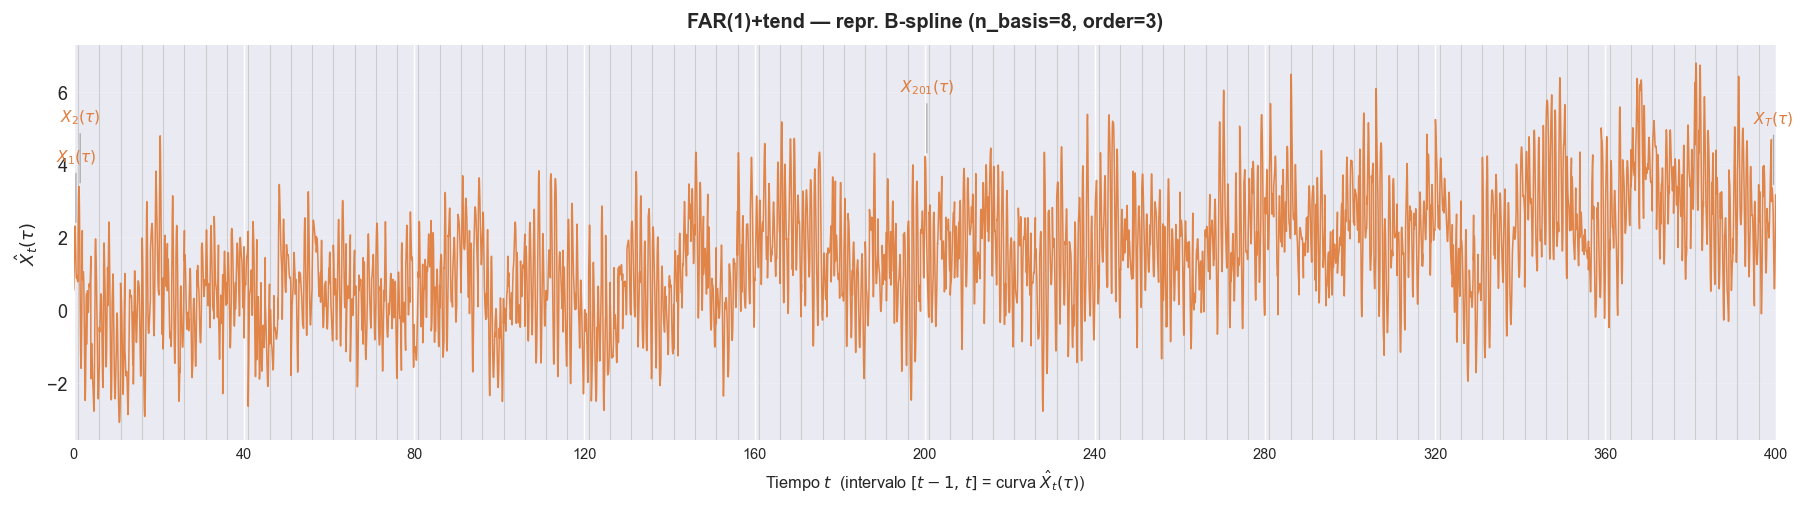

[functional] functional_representation.pkl + theta.csv + fr_config.json


In [15]:
NB_ELEGIDO  = 8     # ← fijado igual que la corrida 11, a propósito
ORD_ELEGIDO = 3

print(f"Base elegida : n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO}")
print(f"Sugerido GCV : n_basis={nb_best}, order={ord_best}"
      + ("   (coinciden)" if (NB_ELEGIDO, ORD_ELEGIDO) == (nb_best, ord_best)
         else "   ← DIFIERE: se mantiene la base de la corrida 11 para que la\n"
              "               comparación sea entre generadores y no entre bases."))

fr = FunctionalRepresentation(method="bspline", n_basis=NB_ELEGIDO,
                              order=ORD_ELEGIDO, center=False)
fr.fit(X_train, grilla)                       # sólo train
THETA       = fr.transform(X, grilla)         # (T, K) serie completa
THETA_train = THETA[idx_train]
print(f"THETA {THETA.shape}  (train={T0}, test={T - T0})")

plot_fts_functional(
    X, grilla, fr=fr, highlight_idx=highlight_idx, separator_every=5,
    title=f"FAR(1)+tend — repr. B-spline (n_basis={NB_ELEGIDO}, order={ORD_ELEGIDO})",
    save_path=str(PATHS["out_report"] / "06_fts_funcional_bspline.png"))
plt.show()

guardar_representacion(PATHS, fr, THETA,
    extra={"T0": int(T0), "prop_train": float(PROP_TRAIN), "ajustado_en": "train",
           "center": bool(fr.center), "n_basis": int(NB_ELEGIDO),
           "order": int(ORD_ELEGIDO), "n_basis_gcv": nb_best, "order_gcv": ord_best})
print("[functional] functional_representation.pkl + theta.csv + fr_config.json")

### 3.3 FPCA generalizado en $L^2$ y diagnóstico

La base B-spline no es ortonormal, de modo que la Gram $W\neq I$ y la
descomposición correcta resuelve el problema propio generalizado
$(W^{1/2}S_\theta W^{1/2})z=\lambda z$. Se ajusta **sólo con entrenamiento**.

In [16]:
Phi  = base_en_grilla(fr, THETA.shape[1])        # (G, K)
fpca = FPCA_L2().fit(THETA_train, Phi, grilla)

_ver = fpca.verificar(THETA_train, fr=fr)
print("Verificación FPCA_L2 (entrenamiento):")
for k, v in _ver.items():
    print(f"  {k:34s} = {v:.3e}" if isinstance(v, float) else f"  {k:34s} = {v}")

cond = _ver["cond_W"]
nota = ("← MUY ALTO: reduzca n_basis" if cond > 1e10 else
        "← alto: vigile las componentes menores" if cond > 1e6 else "(sano)")
print(f"\ncond(W) = {cond:.3e}  {nota}")

assert _ver["todo_ok"], ("Las identidades del FPCA generalizado no se cumplen. "
                         "Si falla err_linealidad_reconstruct_rel, revise center=False.")

Verificación FPCA_L2 (entrenamiento):
  M                                  = 8
  K                                  = 8
  n_ajuste                           = 280
  cond_W                             = 1.027e+01
  err_ortonormalidad_L2              = 2.161e-15
  err_ortonormalidad_gram            = 1.823e-15
  var_explicada                      = 1.000e+00
  err_rutas_reconstruccion           = 8.882e-16
  err_linealidad_reconstruct         = 0.000e+00
  err_linealidad_reconstruct_rel     = 0.000e+00
  err_media_scores                   = 1.792e-16
  err_media_scores_rel               = 7.290e-16
  err_var_scores_vs_lambda           = 2.220e-15
  err_var_scores_vs_lambda_rel       = 4.292e-14
  err_correlacion_lag0               = 2.347e-14
  criterios_evaluados                = ['err_ortonormalidad_L2', 'err_ortonormalidad_gram', 'err_rutas_reconstruccion', 'err_correlacion_lag0', 'err_linealidad_reconstruct_rel', 'err_media_scores_rel', 'err_var_scores_vs_lambda_rel']
  todo_ok      

### 3.4 Espectro FPCA: **la primera verificación del escenario**

Varianza ≠ dinámica. Bajo tendencia esa distinción se vuelve crítica: la deriva
es una dirección de **varianza grande** y **predictibilidad casi perfecta**
(su score es una serie de raíz cuasi-unitaria, $\mathrm{ar1}\to 1$). Se espera
por tanto:

- una FPC con `ar1_propio` muy próximo a 1 — **es la componente de la deriva**,
  y la celda la identifica y la contrasta con $g(\tau)$;
- que esa componente **desplace** a una de las que describían el FAR(1), porque
  $M$ está fijo en 4.

Ese desplazamiento es el mecanismo (2) de la introducción, y aquí se mide.

c:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\.v_1\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\.v_1\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,componente,autovalor,var_ratio,var_acum,ar1_propio,alineacion_g
0,1,1.0439e+00,63.1026%,63.1026%,+0.742,nan
1,2,3.6915e-01,22.3157%,85.4184%,+0.329,nan
2,3,1.4407e-01,8.7090%,94.1274%,+0.119,nan
3,4,5.9765e-02,3.6128%,97.7402%,-0.023,nan
4,5,2.7381e-02,1.6552%,99.3954%,+0.019,nan
5,6,6.8649e-03,0.4150%,99.8104%,+0.022,nan
6,7,2.0347e-03,0.1230%,99.9334%,+0.005,nan
7,8,1.1015e-03,0.0666%,100.0000%,-0.003,nan



K disponibles: 8   ·   sugerencia (var ≥ 95%): M = 4

Componente de la DERIVA: FPC 1
  ar1_propio     = +0.7416   ← esperado ≈ 1 bajo tendencia
  var_ratio      = 63.10%
  alineación g   = nan  (baja: la deriva se reparte entre componentes)

⚠ Ninguna componente tiene ar1 cercano a 1: la deriva no domina el
  espectro. Con TEND_DERIVA bajo esto es esperable, pero entonces el
  escenario mide poco. Considerar subir TEND_DERIVA.


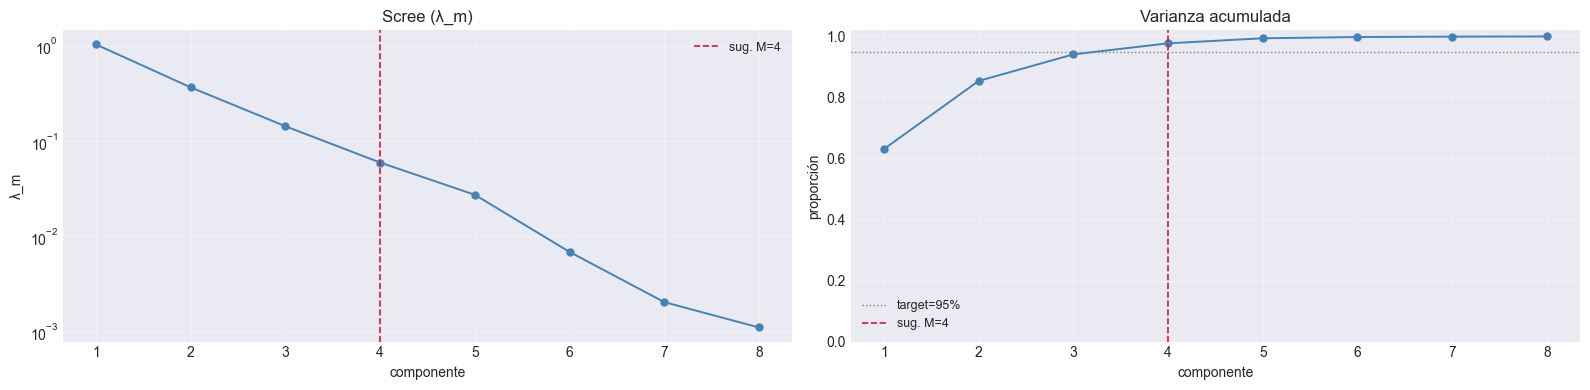

In [17]:
K   = fpca.evals.size
S_a = (THETA_train - fpca.mu_theta) @ (fpca.W @ fpca.B_full)     # (T0, K)
ar1 = (S_a[1:] * S_a[:-1]).sum(0) / np.clip((S_a[:-1] ** 2).sum(0), 1e-12, None)

# Alineación de cada autofunción con la forma de la deriva g(tau), por
# correlación sobre la grilla. La componente de la deriva debe alinearse.
Psi_full = Phi @ fpca.B_full                                      # (G, K)
g_c      = g_tau - g_tau.mean()
alin_g   = np.array([
    abs(float(np.corrcoef(g_c, Psi_full[:, j] - Psi_full[:, j].mean())[0, 1]))
    if np.std(Psi_full[:, j]) > 1e-12 else 0.0
    for j in range(K)])

VAR_TARGET  = 0.95
M_SUGERIDO  = fpca.seleccionar_M(VAR_TARGET)

espectro_df = pd.DataFrame({
    "componente": np.arange(1, K + 1), "autovalor": fpca.evals,
    "var_ratio": fpca.var_ratio, "var_acum": fpca.var_cum,
    "ar1_propio": ar1, "alineacion_g": alin_g,
})
espectro_df.to_csv(PATHS["out_report"] / "12_espectro_fpca.csv", index=False)

display(espectro_df.head(min(15, K)).style.format(
    {"autovalor": "{:.4e}", "var_ratio": "{:.4%}",
     "var_acum": "{:.4%}", "ar1_propio": "{:+.3f}", "alineacion_g": "{:.3f}"})
    .background_gradient(subset=["var_ratio"], cmap="YlGn")
    .background_gradient(subset=["ar1_propio"], cmap="coolwarm", vmin=-1, vmax=1)
    .background_gradient(subset=["alineacion_g"], cmap="Purples", vmin=0, vmax=1))

j_deriva = int(np.argmax(ar1))
print(f"\nK disponibles: {K}   ·   sugerencia (var ≥ {VAR_TARGET:.0%}): M = {M_SUGERIDO}")
print(f"\nComponente de la DERIVA: FPC {j_deriva + 1}")
print(f"  ar1_propio     = {ar1[j_deriva]:+.4f}   ← esperado ≈ 1 bajo tendencia")
print(f"  var_ratio      = {fpca.var_ratio[j_deriva]:.2%}")
print(f"  alineación g   = {alin_g[j_deriva]:.3f}  "
      + ("(alta: la autofunción reproduce la forma de la deriva)"
         if alin_g[j_deriva] > 0.9 else "(baja: la deriva se reparte entre componentes)"))

if ar1[j_deriva] < 0.90:
    print("\n⚠ Ninguna componente tiene ar1 cercano a 1: la deriva no domina el\n"
          "  espectro. Con TEND_DERIVA bajo esto es esperable, pero entonces el\n"
          "  escenario mide poco. Considerar subir TEND_DERIVA.")
else:
    print("\n✓ Hay una componente de raíz cuasi-unitaria: la deriva entró al espectro.")

plot_fpca_scree(fpca.evals, fpca.var_cum, M_SUGERIDO, var_target=VAR_TARGET,
                save_path=str(PATHS["out_report"] / "07_fpca_scree.png"))
plt.show()

### 3.5 `[CONFIG]` Componentes retenidas y **la segunda verificación**

`M_FPCA = 4` es el invariante del estudio (corridas 11, 12, 14, 15, 16) y se
mantiene.

La cifra que importa aquí es `max|media ξ|` en el **bloque de prueba**. En la
corrida 11 —estacionaria— vale **0.063**: los scores del test están centrados
porque la media de train sigue siendo válida. Bajo tendencia debe ser
**mucho mayor**, y esa es la medida directa del mecanismo (1): el centrado
ajustado en train no transfiere.

In [18]:
M_FPCA = 4   # ← invariante del estudio; NO se cambia aquí

assert 1 <= M_FPCA <= fpca.evals.size, f"M_FPCA fuera de [1, {fpca.evals.size}]."
fpca.set_M(int(M_FPCA))
M_fpca = fpca.M

Psi_grid, mu_grid = fpca.Psi_grid, fpca.mu_grid
SCORES       = fpca.transform(THETA)       # (T, M) — base ajustada en train
SCORES_train = SCORES[idx_train]
SCORES_test  = SCORES[idx_test]

MEDIA_XI_TEST_C11 = 0.063   # referencia de la corrida 11 (estacionaria)
media_xi_test = float(np.abs(SCORES_test.mean(0)).max())

print(f"M = {M_fpca}   var. explicada = {fpca.var_cum[M_fpca-1]:.4%}")
print(f"[train] max|media ξ| = {np.abs(SCORES_train.mean(0)).max():.2e}   (≈ 0 por construcción)")
print(f"[test]  max|media ξ| = {media_xi_test:.3f}"
      f"      ← corrida 11 (estacionaria): {MEDIA_XI_TEST_C11}")
print(f"        razón A / 11 = {media_xi_test / MEDIA_XI_TEST_C11:.1f}×")
print(f"[test]  var ξ / λ    = "
      f"{np.array2string(SCORES_test.var(0, ddof=1) / fpca.lambdas, precision=3)}")

print(f"\nmedia de ξ por componente en test: "
      f"{np.array2string(SCORES_test.mean(0), precision=3)}")
print(f"                            train: "
      f"{np.array2string(SCORES_train.mean(0), precision=3)}")

if media_xi_test > 5 * MEDIA_XI_TEST_C11:
    print("\n✓ VERIFICADO: el centrado ajustado en train NO transfiere al test.\n"
          "  Éste es el mecanismo (1) y es el que domina el error de 17_04.")
else:
    print("\n⚠ El descentrado del test es comparable al de la corrida 11: la\n"
          "  tendencia no está produciendo el efecto buscado. Revisar TEND_DERIVA.")

# La componente de la deriva debe quedar DENTRO de las M retenidas: si no,
# 17_03 y 17_04 no podrian marcarla y sus lecturas especificas quedarian mudas.
if j_deriva >= M_fpca:
    print(f"\n(!) La componente de mayor ar1 es la FPC {j_deriva + 1}, "
          f"FUERA de las M={M_fpca} retenidas.")
    print("    Se reasigna a la de mayor ar1 ENTRE LAS RETENIDAS para que "
          "17_03/17_04 la marquen.")
    j_deriva = int(np.argmax(ar1[:M_fpca]))
    print(f"    nueva componente de la deriva: FPC {j_deriva + 1} "
          f"(ar1 = {ar1[j_deriva]:+.4f})")
assert j_deriva < M_fpca


M = 4   var. explicada = 97.7402%
[train] max|media ξ| = 1.79e-16   (≈ 0 por construcción)
[test]  max|media ξ| = 1.528      ← corrida 11 (estacionaria): 0.063
        razón A / 11 = 24.3×
[test]  var ξ / λ    = [1.008 0.875 1.146 1.149]

media de ξ por componente en test: [-1.528  0.037 -0.323  0.014]
                            train: [ 1.792e-16 -2.379e-18  1.117e-16  9.021e-17]

✓ VERIFICADO: el centrado ajustado en train NO transfiere al test.
  Éste es el mecanismo (1) y es el que domina el error de 17_04.


## 4. Datasets AR($p$) sobre los scores

### 4.1 Estandarización

El estandarizador se ajusta **sólo con train** y registra `n_ajuste` para que
esa disciplina sea auditable desde el artefacto y no una promesa del notebook.

Bajo tendencia el `[test] media` de los scores estandarizados es la traducción
del descentrado de §3.5 a la escala en que trabaja MATLAB. Es el número que hay
que tener presente al leer las trazas: el muestreador ve un regresor que en el
test vive en una región del espacio que **no visitó** durante el entrenamiento.

[holdout] ajustado con 280 filas = T0 (train[1:280]) → ok=True

SCORES_STD (400, 4)
  [train] max|media| = 8.56e-17  (≈0)
  [train] max|std-1| = 6.66e-16  (≈0)
  [test]  media = [-1.499  0.062 -0.853  0.059]
  [test]  std   = [1.001 0.933 1.068 1.069]

  → el test está a 1.50 sd del origen en el que se entrenó.
  → 26 de 120 orígenes de test (21.7%) caen FUERA del rango de train
    en al menos una componente: el modelo está extrapolando, no interpolando.

[functional] artefactos FPCA · cond_W = 1.027e+01


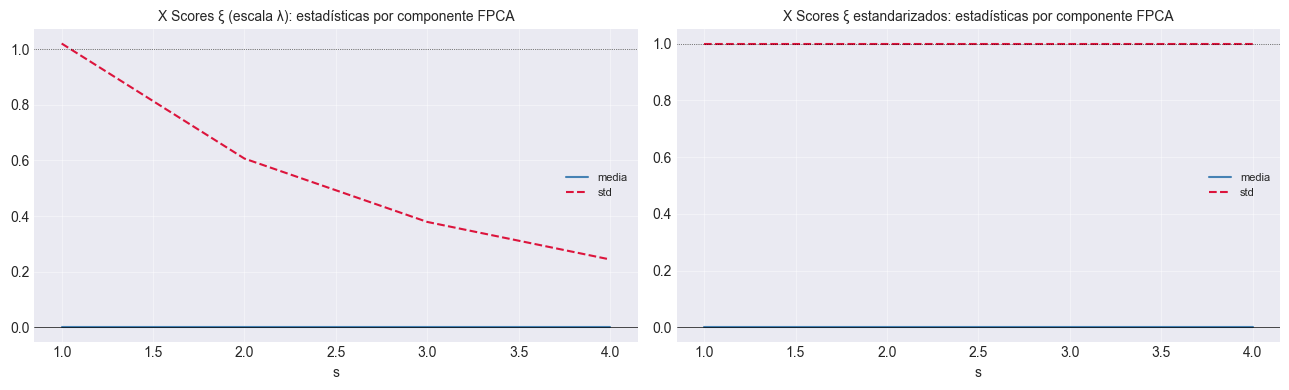

In [19]:
scores_standardizer = DataStandardizer(method="zscore_column", ddof=0)
scores_standardizer.fit(SCORES_train, etiqueta=f"train[1:{T0}]")

_chk = scores_standardizer.verificar_ajuste(T0)
print(f"[holdout] ajustado con {_chk['n_ajuste']} filas = T0 "
      f"({_chk['etiqueta_ajuste']}) → ok={_chk['ajuste_ok']}")

SCORES_STD       = scores_standardizer.transform(SCORES)
SCORES_STD_train = SCORES_STD[idx_train]
SCORES_STD_test  = SCORES_STD[idx_test]

print(f"\nSCORES_STD {SCORES_STD.shape}")
print(f"  [train] max|media| = {np.abs(SCORES_STD_train.mean(0)).max():.2e}  (≈0)")
print(f"  [train] max|std-1| = {np.abs(SCORES_STD_train.std(0) - 1).max():.2e}  (≈0)")
print(f"  [test]  media = {np.array2string(SCORES_STD_test.mean(0), precision=3)}")
print(f"  [test]  std   = {np.array2string(SCORES_STD_test.std(0),  precision=3)}")
print(f"\n  → el test está a {np.abs(SCORES_STD_test.mean(0)).max():.2f} sd del origen "
      f"en el que se entrenó.")

# Rango cubierto: cuántos orígenes de test caen fuera del soporte de train.
lo, hi = SCORES_STD_train.min(0), SCORES_STD_train.max(0)
fuera  = ((SCORES_STD_test < lo) | (SCORES_STD_test > hi)).any(axis=1)
print(f"  → {fuera.sum()} de {len(fuera)} orígenes de test ({fuera.mean():.1%}) caen "
      f"FUERA del rango de train\n    en al menos una componente: el modelo está "
      f"extrapolando, no interpolando.")

guardar_estandarizador(PATHS, scores_standardizer)
_res = guardar_fpca(PATHS, fpca, SCORES, SCORES_STD=SCORES_STD,
                    meta_extra={"T0": int(T0)})
print(f"\n[functional] artefactos FPCA · cond_W = {_res['meta']['cond_W']:.3e}")

plot_diagnostico_estandarizacion(
    SCORES_train, SCORES_STD_train, np.arange(1, M_fpca + 1),
    labels=("Scores ξ (escala λ)", "Scores ξ estandarizados"),
    title="estadísticas por componente FPCA",
    save_path=str(PATHS["out_report"] / "08_diagnostico_estandarizacion.png"))
plt.show()

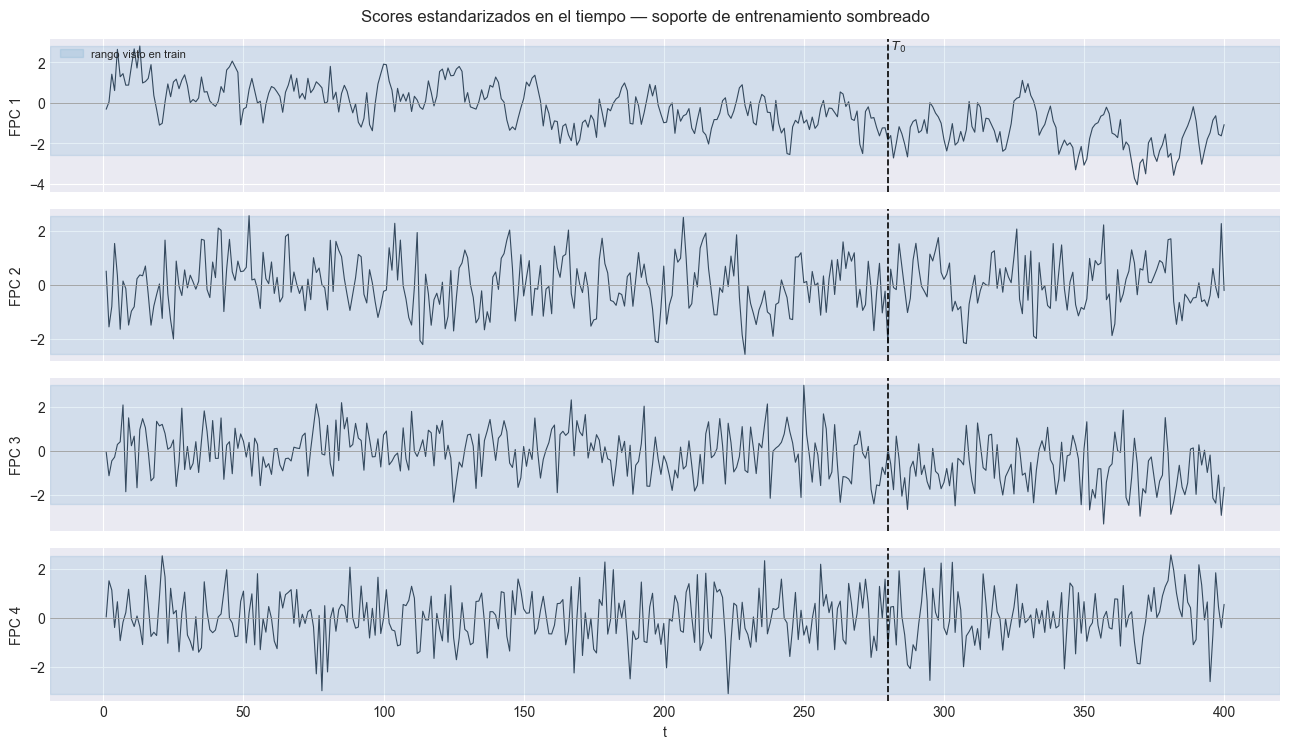

In [20]:
# Los scores estandarizados en el tiempo, con el corte marcado. Es la figura
# que hace visible por qué el problema no es de "más flexibilidad": la serie
# de la componente de deriva sale del rango de entrenamiento y no vuelve.
fig, axes = plt.subplots(M_fpca, 1, figsize=(13, 1.9 * M_fpca), sharex=True,
                         squeeze=False)
for k in range(M_fpca):
    ax = axes[k, 0]
    ax.plot(t_idx, SCORES_STD[:, k], lw=0.8, color="#34495e")
    ax.axvline(T0, color="k", ls="--", lw=1.2)
    ax.axhspan(SCORES_STD_train[:, k].min(), SCORES_STD_train[:, k].max(),
               color="#2980b9", alpha=0.12,
               label="rango visto en train" if k == 0 else None)
    ax.axhline(0, color="0.6", lw=0.6)
    ax.set_ylabel(f"FPC {k+1}")
    if k == 0:
        ax.legend(fontsize=8, loc="upper left")
        ax.text(T0, ax.get_ylim()[1], r" $T_0$", va="top", fontsize=9)
axes[-1, 0].set_xlabel("t")
fig.suptitle("Scores estandarizados en el tiempo — soporte de entrenamiento sombreado",
             fontsize=12)
fig.tight_layout()
fig.savefig(PATHS["out_report"] / "13_scores_tiempo.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.2 Diagnóstico de rezagos (sólo train)

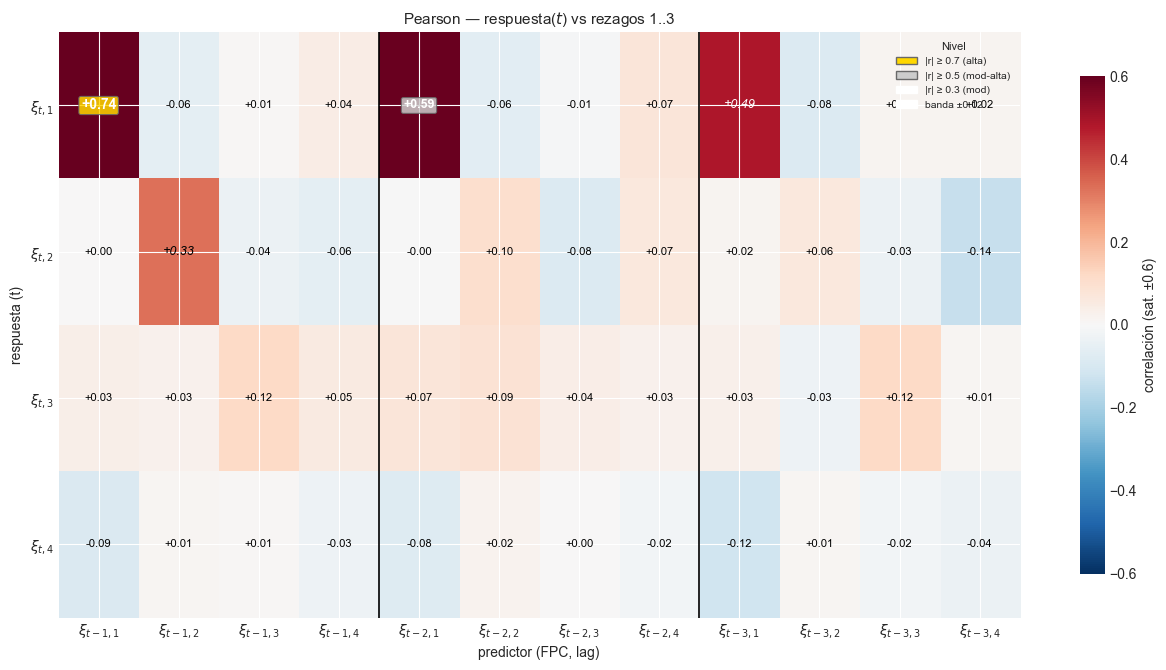

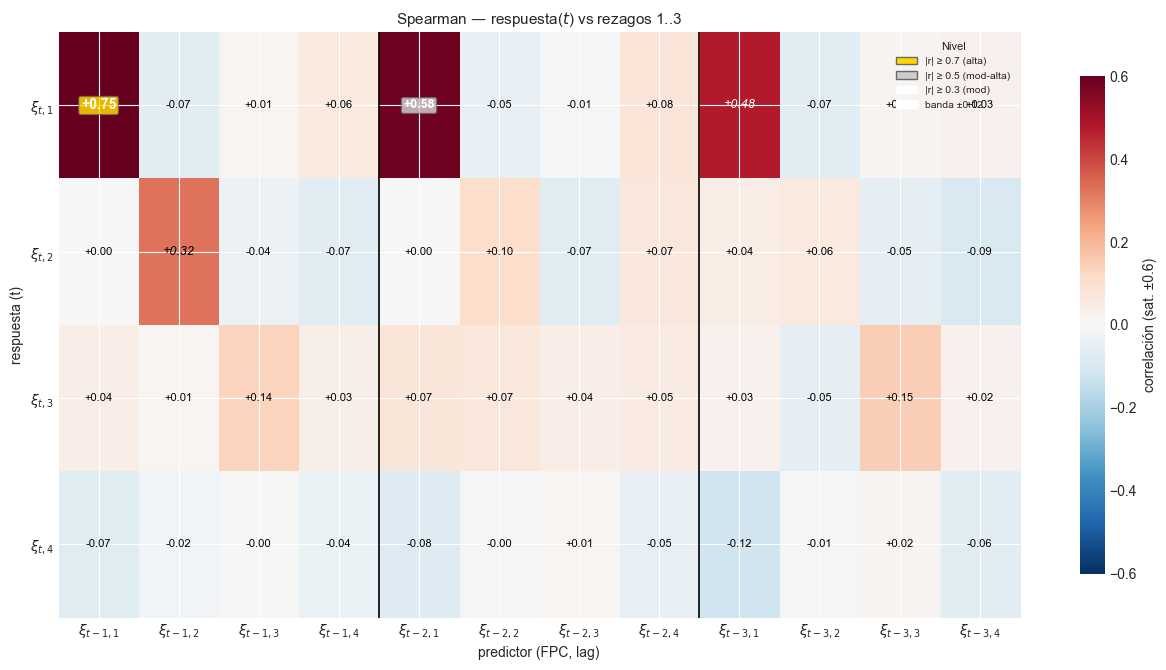

Bajo tendencia la diagonal del rezago 1 se satura cerca de 1 en la
componente de la deriva. Es correlación espuria por raíz común, no
dependencia dinámica: no interpretarla como señal del FAR(1).


In [21]:
N_LAGS_MAX = 3
T_theta, K_total = SCORES_STD_train.shape

def _spearman(Y, Xm):
    """Spearman columna a columna vía rangos (pandas, sin scipy)."""
    Yc = pd.DataFrame(Y).rank().to_numpy(); Yc = Yc - Yc.mean(0)
    Xc = pd.DataFrame(Xm).rank().to_numpy(); Xc = Xc - Xc.mean(0)
    return (Yc.T @ Xc) / np.outer(np.sqrt((Yc**2).sum(0)), np.sqrt((Xc**2).sum(0)))

corr_p = np.zeros((K_total, K_total * N_LAGS_MAX))
corr_s = np.zeros_like(corr_p)
col_labels = []
y_block = SCORES_STD_train[N_LAGS_MAX:, :]

for lag in range(1, N_LAGS_MAX + 1):
    x_block = SCORES_STD_train[N_LAGS_MAX - lag : T_theta - lag, :]
    sp = _spearman(y_block, x_block)
    for j in range(K_total):
        c = (lag - 1) * K_total + j
        for k in range(K_total):
            corr_p[k, c] = np.corrcoef(y_block[:, k], x_block[:, j])[0, 1]
        corr_s[:, c] = sp[:, j]
        col_labels.append(rf"$\xi_{{t-{lag},{j+1}}}$")

row_labels = [rf"$\xi_{{t,{k+1}}}$" for k in range(K_total)]
band = 1.96 / np.sqrt(len(y_block))

for M_corr, nombre, arch in ((corr_p, "Pearson", "09a"), (corr_s, "Spearman", "09b")):
    plot_rezagos_heatmap(
        M_corr, col_labels, row_labels,
        title=f"{nombre} — respuesta($t$) vs rezagos 1..{N_LAGS_MAX}",
        n_lags_max=N_LAGS_MAX, K_total=K_total, band=band, vclip=0.6,
        save_path=str(PATHS["out_report"] / f"{arch}_rezagos_{nombre.lower()}.png"))
    plt.show()

print("Bajo tendencia la diagonal del rezago 1 se satura cerca de 1 en la\n"
      "componente de la deriva. Es correlación espuria por raíz común, no\n"
      "dependencia dinámica: no interpretarla como señal del FAR(1).")

### 4.3 `[CONFIG]` Orden AR y construcción de los datasets

Los rezagos del primer origen de prueba vienen del final del bloque de
entrenamiento: son observaciones pasadas disponibles en cada origen, de modo
que su uso es el condicionamiento de la predicción a $h=1$, no fuga.

`N_LAGS = 1` igual que las corridas 11–16.

In [22]:
N_LAGS        = 1
COMPONENT_IDX = list(range(SCORES_STD.shape[1]))   # base-0; los nombres usan idx+1

n_components = len(COMPONENT_IDX)
n_train_eff  = T0 - N_LAGS
n_test_eff   = T - T0

assert T0 > N_LAGS and len(set(COMPONENT_IDX)) == n_components

cov_names = [f"fpc_{COMPONENT_IDX[j] + 1}_lag{lag}"
             for lag in range(1, N_LAGS + 1)
             for j in range(n_components)]

print(f"componentes : {n_components} → índices {COMPONENT_IDX}")
print(f"N_LAGS      : {N_LAGS}   ·   p = {len(cov_names)} covariables")
print(f"n_train_eff : {n_train_eff}   n_test_eff : {n_test_eff}")
print(f"cov_names   : {cov_names}")

componentes : 4 → índices [0, 1, 2, 3]
N_LAGS      : 1   ·   p = 4 covariables
n_train_eff : 279   n_test_eff : 120
cov_names   : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1']


In [23]:
SCORES_sel = SCORES_STD[:, COMPONENT_IDX]

def _dataset_bloque(k, t_ini, t_fin):
    """Respuesta en t ∈ [t_ini, t_fin) y predictores en t-1 … t-N_LAGS."""
    t_idx_b = np.arange(t_ini, t_fin)
    X_cols  = np.hstack([SCORES_sel[t_idx_b - lag, :] for lag in range(1, N_LAGS + 1)])
    return pd.DataFrame(np.column_stack([SCORES_sel[t_idx_b, k], X_cols]),
                        columns=[f"fpc_{COMPONENT_IDX[k] + 1}"] + cov_names)

dfs_train = {k: _dataset_bloque(k, N_LAGS, T0) for k in range(n_components)}
dfs_test  = {k: _dataset_bloque(k, T0,     T)  for k in range(n_components)}

manifest = {
    "scores_scale":  "standardized_zscore_ddof0",
    "n_components":  n_components,
    "n_lags":        int(N_LAGS),
    "component_idx": [int(i) for i in COMPONENT_IDX],
    "cov_names":     cov_names,
    "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
    "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
    "ajuste_en": "train",
}
guardar_datasets_ar(PATHS, dfs_train, dfs_test, manifest)
print(f"[functional] {2*n_components} datasets + datasets_manifest.json")
for k in range(n_components):
    print(f"  fpc_{COMPONENT_IDX[k]+1}: train {dfs_train[k].shape} · test {dfs_test[k].shape}")

[functional] 8 datasets + datasets_manifest.json
  fpc_1: train (279, 5) · test (120, 5)
  fpc_2: train (279, 5) · test (120, 5)
  fpc_3: train (279, 5) · test (120, 5)
  fpc_4: train (279, 5) · test (120, 5)


## 5. `[CONFIG]` Hiperparámetros y configuración MCMC

Esto es el **contrato con MATLAB**: `psbp_fd_iteracion.m` lee estos valores del
JSON y no los tiene escritos a mano, incluida `seed_base`.

`MCMC_CONFIG`, `N_CHAINS` y los priors son **idénticos a los de la corrida 11**,
igual que en las corridas 12–16: cambiarlos convertiría la comparación entre
escenarios en una comparación entre ajustes.

El prior $E[\pi]=0.90$ sobre el propio rezago está aquí **bien orientado por el
motivo equivocado**: bajo tendencia el propio rezago sí es fuertemente
predictivo, pero por la raíz común y no por la dinámica del FAR(1). Que el eje
3 lo confirme no es evidencia de que el modelo recuperó la estructura; es la
lectura que `_03 §6.1` matiza.

Ojo con la doble acepción de `M`: aquí, dentro de `mcmc_config`, es el tamaño
de la grilla de localización $G^*$ del stick-breaking, **no** el número de
componentes FPCA.

In [24]:
MCMC_CONFIG = {"nsim": 2000, "burn": 500, "N": 35, "M": 35}
N_CHAINS    = 3

print(f"MCMC_CONFIG : {MCMC_CONFIG}")
print(f"N_CHAINS    : {N_CHAINS} cadenas por componente "
      f"→ {N_CHAINS * n_components} jobs en MATLAB")
print(f"Draws posteriores por score: "
      f"({MCMC_CONFIG['nsim']} - {MCMC_CONFIG['burn']}) × {N_CHAINS} = "
      f"{(MCMC_CONFIG['nsim'] - MCMC_CONFIG['burn']) * N_CHAINS}")

MCMC_CONFIG : {'nsim': 2000, 'burn': 500, 'N': 35, 'M': 35}
N_CHAINS    : 3 cadenas por componente → 12 jobs en MATLAB
Draws posteriores por score: (2000 - 500) × 3 = 4500


In [25]:
# Priors globales — idénticos a la corrida 11
HP_GLOBAL = {"atau": 2.0, "btau": 0.5, "ag": 2.0, "bg": 0.5,
             "mumu": 0.0, "taumu": 1.0, "pwj": 0.5}

# Priors por tipo de covariable: (apij, bpij, mupsij, taupsij)
HP_BY_TYPE = {
    "own_lag1":  (9.0, 1.0, 0.0, 1.0),   # E[pi] = 0.90 — el propio rezago 1
    "cross_lag": (1.0, 1.0, 0.0, 1.0),   # E[pi] = 0.50 — los cruzados
}

def _clasificar(nombre, k_modelo):
    return ("own_lag1" if nombre == f"fpc_{COMPONENT_IDX[k_modelo] + 1}_lag1"
            else "cross_lag")

HYPERPARAMS_LIST = []
for k in range(n_components):
    tipos = [_clasificar(nm, k) for nm in cov_names]
    vals  = np.array([HP_BY_TYPE[t] for t in tipos], dtype=float)   # (p, 4)
    HYPERPARAMS_LIST.append({**HP_GLOBAL,
        "apij": vals[:, 0], "bpij": vals[:, 1],
        "mupsij": vals[:, 2], "taupsij": vals[:, 3]})

for k in range(n_components):
    hp = HYPERPARAMS_LIST[k]
    print(f"\nComponente k={k}  (fpc_{COMPONENT_IDX[k]+1})")
    print(f"  {'variable':<22} {'tipo':<11} {'apij':>6} {'bpij':>6} {'E[pi]':>7}")
    for j, nm in enumerate(cov_names):
        a, b = hp["apij"][j], hp["bpij"][j]
        marca = "  ◄" if _clasificar(nm, k) == "own_lag1" else ""
        print(f"  {nm:<22} {_clasificar(nm, k):<11} {a:>6.1f} {b:>6.1f} "
              f"{a/(a+b):>7.3f}{marca}")


Componente k=0  (fpc_1)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             own_lag1       9.0    1.0   0.900  ◄
  fpc_2_lag1             cross_lag      1.0    1.0   0.500
  fpc_3_lag1             cross_lag      1.0    1.0   0.500
  fpc_4_lag1             cross_lag      1.0    1.0   0.500

Componente k=1  (fpc_2)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             cross_lag      1.0    1.0   0.500
  fpc_2_lag1             own_lag1       9.0    1.0   0.900  ◄
  fpc_3_lag1             cross_lag      1.0    1.0   0.500
  fpc_4_lag1             cross_lag      1.0    1.0   0.500

Componente k=2  (fpc_3)
  variable               tipo          apij   bpij   E[pi]
  fpc_1_lag1             cross_lag      1.0    1.0   0.500
  fpc_2_lag1             cross_lag      1.0    1.0   0.500
  fpc_3_lag1             own_lag1       9.0    1.0   0.900  ◄
  fpc_4_lag1             cross_lag      1.0    1.0   0.500

Componente k=3  (fpc_4)
  vari

In [26]:
hp_artifact = {
    "global":       HP_GLOBAL,
    "by_type":      HP_BY_TYPE,
    "mcmc_config":  MCMC_CONFIG,
    "n_iter":       N_CHAINS,
    "seed_scheme":  "seed_base + chain*9973 + k*31",
    "escenario_id": ESCENARIO_ID,     # cadena "A"; el .m usa %s por esto
    "replica_id":   int(REPLICA_ID),
    "seed_base":    int(SEED),     # MATLAB la lee de aquí (ya no está hardcodeada)
    "scores_scale": "standardized_zscore_ddof0",
    "partition": {
        "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
        "n_train_eff": int(n_train_eff), "n_test_eff": int(n_test_eff),
        "train_files": [f"dataset_fpc_{COMPONENT_IDX[k]+1}_train.csv"
                        for k in range(n_components)],
        "test_files":  [f"dataset_fpc_{COMPONENT_IDX[k]+1}_test.csv"
                        for k in range(n_components)],
    },
    "hyperparams_list": [
        {"component_k": k, "fpc_idx": int(COMPONENT_IDX[k] + 1),
         "hyperparams": {key: (v.tolist() if isinstance(v, np.ndarray) else v)
                         for key, v in HYPERPARAMS_LIST[k].items()}}
        for k in range(n_components)
    ],
}
guardar_hiperparametros(PATHS, hp_artifact)
print(f"✓ hyperparameters.json → {PATHS['out_artefact']}")

✓ hyperparameters.json → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\escenario_A_r01


## 6. Configuración de evaluación, líneas base y verificación del contrato

`objetivo_evaluacion` y `modo_residuo` se declaran aquí porque cambian el
significado de toda la evaluación y no deben quedar como una decisión implícita
del notebook `_04`. Son los mismos de la corrida 11.

El bloque `estratificacion` declara el estado verdadero $b(t)$ **con su
advertencia**, siguiendo el patrón de la corrida 16: la advertencia viaja con
los datos, no sólo en el texto del notebook.

In [27]:
eval_config = {
    "scheme":      "holdout_temporal",
    "T": int(T), "T0": int(T0), "prop_train": float(PROP_TRAIN),
    "horizons":    [1],
    "n_lags":      int(N_LAGS),
    "scores_scale": "standardized_zscore_ddof0",
    # Contra QUÉ se mide el error y con qué banda. Declarado explícitamente:
    #   curva_verdadera + modo_residuo "ninguno" ⇒ la banda cubre la curva
    #   PROYECTADA sobre las M autofunciones y se contrasta con X_t(tau).
    "objetivo_evaluacion": "curva_verdadera",
    "modo_residuo":        "ninguno",
    "nivel_credibilidad":  0.95,
    "ventana_movil": {"w": [10, 20, 40], "paso": 1, "solapadas": True},
    "metrics_scores": ["RMSE", "R2", "razon_dispersion"],
    "metrics_curvas": ["MISE", "RMSE_funcional"],
    "metrics_dist":   ["CRPS", "energy_score", "cobertura_95", "PIT"],
    # ── Estado verdadero del generador ───────────────────────────────────────
    "estratificacion": {
        "variable":    "b_t",
        "descripcion": "deriva determinista acumulada b(t) = TEND_DERIVA * u(t)",
        "fuente":      "reports/simulaciones/<EXPERIMENT_ID>/10_estado_tendencia.csv",
        "metodo":      "cuantiles del estado verdadero (estratos_por_cuantil)",
        "n_estratos":  4,
        "etiquetas":   ["deriva Q1", "deriva Q2", "deriva Q3", "deriva Q4"],
        "advertencia": (
            "b(t) es MONOTONA en t, de modo que los estratos por nivel de deriva "
            "son intervalos temporales contiguos y el estrato mas alto coincide "
            "casi exactamente con el bloque de prueba. La cobertura condicional "
            "de 17_04 §9 y la comparacion train/test de 17_04 §4 miden por tanto "
            "LO MISMO. Es la tesis del escenario, no un defecto, pero sin "
            "declararlo el desplome de cobertura se leeria como perdida de "
            "GENERALIZACION cuando es perdida de VIGENCIA DEL CENTRADO. Para "
            "separar ambos efectos habria que usar TEND_FORMA='cuadratica', que "
            "concentra la deriva dentro del test."
        ),
    },
    "tendencia": {
        "deriva_total": float(TEND_DERIVA),
        "forma":        TEND_FORMA,
        "inclinacion":  float(TEND_INCLINACION),
        "g_medio":      g_medio,
        "componente_deriva_fpc": int(j_deriva + 1),
        "ar1_componente_deriva": float(ar1[j_deriva]),
        "media_xi_test_max":     media_xi_test,
        "media_xi_test_c11_ref": MEDIA_XI_TEST_C11,
    },
}
guardar_config_evaluacion(PATHS, eval_config)
print("[out_artefact] eval_config.json")
for k, v in eval_config.items():
    print(f"  {k:22s}: {v}")

[out_artefact] eval_config.json
  scheme                : holdout_temporal
  T                     : 400
  T0                    : 280
  prop_train            : 0.7
  horizons              : [1]
  n_lags                : 1
  scores_scale          : standardized_zscore_ddof0
  objetivo_evaluacion   : curva_verdadera
  modo_residuo          : ninguno
  nivel_credibilidad    : 0.95
  ventana_movil         : {'w': [10, 20, 40], 'paso': 1, 'solapadas': True}
  metrics_scores        : ['RMSE', 'R2', 'razon_dispersion']
  metrics_curvas        : ['MISE', 'RMSE_funcional']
  metrics_dist          : ['CRPS', 'energy_score', 'cobertura_95', 'PIT']
  estratificacion       : {'variable': 'b_t', 'descripcion': 'deriva determinista acumulada b(t) = TEND_DERIVA * u(t)', 'fuente': 'reports/simulaciones/<EXPERIMENT_ID>/10_estado_tendencia.csv', 'metodo': 'cuantiles del estado verdadero (estratos_por_cuantil)', 'n_estratos': 4, 'etiquetas': ['deriva Q1', 'deriva Q2', 'deriva Q3', 'deriva Q4'], 'adverten

### 6.1 Líneas base

Aquí la lectura **se invierte respecto de la corrida 11**. Bajo tendencia la
serie es casi un paseo aleatorio en su componente dominante, de modo que
`persistencia_lag1` —predecir $\hat X_t = X_{t-1}$— se vuelve fuerte, y
`media_incondicional` —anclada a la media de train— se vuelve pésima.

Que el PSBP-FD gane a la media incondicional **no dice nada**: cualquier cosa lo
hace. La comparación informativa es contra **persistencia**, y si el PSBP-FD no
le gana, la conclusión es que el modelo no está aportando sobre el
des-tendenciado trivial que la persistencia implementa de forma implícita.

In [28]:
baselines_df = tabla_baselines(SCORES_STD, T0, estandarizador=scores_standardizer,
                               fpca=fpca, X_obs=X_true, tau=grilla, h=1)
baselines_df.to_csv(PATHS["out_report"] / "30_baselines_test.csv")
display(baselines_df.style.format("{:.4f}", na_rep="—")
        .set_caption("Líneas base — bloque de prueba, h=1, contra la curva VERDADERA"))

if "RMSE_scores_prom" in baselines_df.columns:
    r_med = baselines_df.loc["media_incondicional", "RMSE_scores_prom"]
    r_per = baselines_df.loc["persistencia_lag1",   "RMSE_scores_prom"]
    print(f"\npersistencia / media incondicional = {r_per / r_med:.3f}")
    print("  < 1  ⇒ la persistencia gana: la serie se comporta como paseo aleatorio.")
    print("        Es lo esperado bajo tendencia y es la comparación que importa\n"
          "        para el PSBP-FD en 17_04 §10 (no la media incondicional).")

,n_test,RMSE_fpc1,RMSE_fpc2,RMSE_fpc3,RMSE_fpc4,RMSE_scores_prom,R2_scores_prom,MISE,RMSE_funcional
modelo,,,,,,,,,
media_incondicional,120.0000,1.8024,0.9352,1.3666,1.0711,1.2938,-0.7210,4.0817,2.0203
persistencia_lag1,120.0000,0.6871,1.1180,1.3906,1.4187,1.1536,-0.3403,1.3886,1.1784



persistencia / media incondicional = 0.892
  < 1  ⇒ la persistencia gana: la serie se comporta como paseo aleatorio.
        Es lo esperado bajo tendencia y es la comparación que importa
        para el PSBP-FD en 17_04 §10 (no la media incondicional).


In [29]:
informe = verificar_contrato(PATHS)
print(f"contrato_ok = {informe['contrato_ok']}   "
      f"(M={informe['M']}, K={informe['K']}, T0={informe['T0']}, "
      f"n_components={informe['n_components']})")
print(f"estandarizador ajustado con {informe.get('estandarizador_n_ajuste')} filas (T0={informe['T0']})")
print(f"verificación FPCA: todo_ok = {informe['verificacion_fpca']['todo_ok']}")
if not informe["contrato_ok"]:
    print("\nPROBLEMAS:")
    for p in informe.get("problemas", []):
        print(f"  - {p}")

print(f"\n{'='*66}")
print("RESUMEN DEL ESCENARIO A")
print(f"{'='*66}")
print(f"  deriva total           : {TEND_DERIVA}  ({razon_deriva_sd:.2f} sd)")
print(f"  forma / inclinación    : {TEND_FORMA} / {TEND_INCLINACION}")
print(f"  desfase train↔test     : {b_t[T0:].mean() - b_t[:T0].mean():.3f}")
print(f"  FPC de la deriva       : {j_deriva + 1}  (ar1 = {ar1[j_deriva]:+.4f})")
print(f"  max|media ξ| en test   : {media_xi_test:.3f}   "
      f"(corrida 11: {MEDIA_XI_TEST_C11})")
print(f"  orígenes extrapolando  : {fuera.mean():.1%}")
print(f"{'='*66}\nSiguiente paso, en MATLAB desde esta carpeta:\n"
      f"  >> psbp_fd_iteracion\n"
      f"EXPERIMENT_ID = {EXPERIMENT_ID}\n{'='*66}")

contrato_ok = True   (M=4, K=8, T0=280, n_components=4)
estandarizador ajustado con 280 filas (T0=280)
verificación FPCA: todo_ok = True

RESUMEN DEL ESCENARIO A
  deriva total           : 3.0  (2.55 sd)
  forma / inclinación    : lineal / 0.0
  desfase train↔test     : 1.504
  FPC de la deriva       : 1  (ar1 = +0.7416)
  max|media ξ| en test   : 1.528   (corrida 11: 0.063)
  orígenes extrapolando  : 21.7%
Siguiente paso, en MATLAB desde esta carpeta:
  >> psbp_fd_iteracion
EXPERIMENT_ID = escenario_A_r01
